In [1]:
import sys
print("Python executable:", sys.executable)

import numpy as np
import pandas as pd
import scipy
import statsmodels
import dill
import torch
import matplotlib

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("scipy", scipy.__version__)
print("matplotlib", matplotlib.__version__)
print("statsmodels", statsmodels.__version__)
print("dill", dill.__version__)
print("torch", torch.__version__, "cuda available:", torch.cuda.is_available())

Python executable: /blue/juannanzhou/arindam.sarkar/.conda/envs/gpy4/bin/python
numpy 2.3.1
pandas 2.3.3
scipy 1.17.0
matplotlib 3.10.3
statsmodels 0.14.6
dill 0.4.1
torch 2.7.1 cuda available: False


In [2]:
import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference")
sys.path.insert(0, str(PROJECT_ROOT))

import src.prepare_data
importlib.reload(src.prepare_data)

from src.prepare_data import yeast_geno_data, yeast_fitness_data, yeast_data, get_abs_pos

In [3]:
from pathlib import Path

paths = [
    Path("/orange/juannanzhou/MarginalEpistasis/data/geno_top_60.npy"),  # adjust if needed
    Path("/orange/juannanzhou/MarginalEpistasis/data/index_top_60.tsv"),
    Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference/data/snp_info_complete.tsv"),
    Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference/data/gene_info.csv"),
]
for p in paths:
    print(p, "exists:", p.exists())

/orange/juannanzhou/MarginalEpistasis/data/geno_top_60.npy exists: True
/orange/juannanzhou/MarginalEpistasis/data/index_top_60.tsv exists: True
/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference/data/snp_info_complete.tsv exists: True
/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference/data/gene_info.csv exists: True


In [4]:
def get_abs_pos(chrom, chrom_pos):
    return (chrom_pos - 1) + dict(enumerate(chr_offsets))[chrom - 1]    


yeast_chr_lengths = [
    230218, 813184, 316620, 1531933, 576874, 270161, 1090940, 562643,
    439888, 745751, 666816, 1078177, 924431, 784333, 1091291, 948066
]

yeast_chr_size = np.array(yeast_chr_lengths).sum()

chr_labels_arabic = [str(i) for i in range(1, 17)]
chr_offsets = np.cumsum([0] + yeast_chr_lengths[:-1])

def calc_LOD_vectorized(y, X):
    """
    Vectorized function for calculating log odds 
    X: n X L; binary genotype matrix
    y: n
    """
    X_ = -1 * (X - 1)
    n = len(y)
    means = np.matmul(y.T, X) / X.sum(axis=0)
    means_ = np.matmul(y.T, X_) / X_.sum(axis=0)
    preds = (X * means) + (X_ * means_)
    res = (preds.T - y) # residuals
    rss1 = np.var(res, axis=1)
    rss0 = np.var(y)
    lods = (n / 2.0) * np.log10(rss0 / rss1)
    
    return lods

### Load data

In [5]:
# load genotype data

path = Path("/orange/juannanzhou/MarginalEpistasis/data/")
geno_data_path = path / "geno_top_60.npy"
ids_path = path / "index_top_60.tsv"
snp_info_path = "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference/data/snp_info_complete.tsv"
gene_info_path = "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/4_qtl_inference/data/gene_info.csv"

### three ways to code SNP position: SNP index; Absolute genomic position [0, sum of chrom sizes]; Chromosome position (chrom, position)
geno_data = yeast_geno_data(geno_data_path, ids_path, snp_info_path, gene_info_path, gpu_device="cpu") #change to 'gpu'while on a GPU node! 
print(geno_data.geno_t.device)
geno_data.snp_info = geno_data.snp_info.drop(columns='Index')
geno_data.snp_info['abs_pos'] = [get_abs_pos(*list(geno_data.snp_info.loc[i][['Chromosome', 'Position (bp)']])) for i in range(len(geno_data.snp_info))]
geno_data.sub_sample_snps(r2_threshold=1) # only retain SNPs not in complete LD 

[yeast_geno_data] Using device: cpu
cpu


In [9]:
print("Total SNPs:", geno_data.snp_info.shape[0])
print("Pruned SNPs:", len(geno_data.loci_chosen))

Total SNPs: 41594
Pruned SNPs: 37339


In [10]:
# fitness data
treatment = 'Pulvinatal'
conditions = ['CON', 'HMIC', 'FMIC', 'DMIC']

dfs_indexed = []
for con in conditions:
    file = f"/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Joint_inference/Filtered/PUL/{con}/fitness_ALLreps_with_ids.tsv"
    df = pd.read_csv(file, sep="\t")
    dfs_indexed.append(df.set_index("ID")[["s", "stderr(s)"]])

dfs_merged = pd.concat(dfs_indexed, axis=1).dropna()
dfs_merged = dfs_merged.rename(columns={"s": "mean_log_fit", "stderr(s)": "std_log_fit"})

fitness_data = yeast_fitness_data(treatment, conditions, in_path=None)
fitness_data.df_fits = dfs_merged

In [11]:
# combine genotype and phenotype data
data = yeast_data(geno_data, fitness_data)
main_effects = data.get_main_effects(geno_data.loci_chosen)

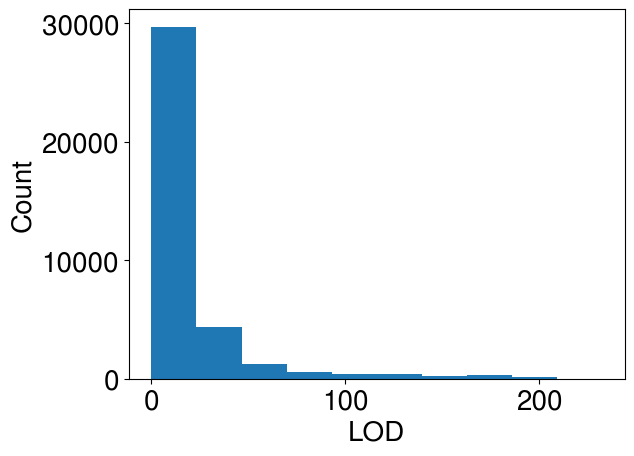

In [13]:
import matplotlib.pyplot as plt

X = data.geno[:, geno_data.loci_chosen]
y = np.array(data.fitness['mean_log_fit'].iloc[:, 1])

lods = calc_LOD_vectorized(y, X) # calculate log odds

plt.hist(lods)
plt.xlabel("LOD")
plt.ylabel("Count")
plt.show()

In [14]:
treatments = ['C', 'H', 'F', 'D']

X = data.geno[:, geno_data.loci_chosen]

LODS_df = {}

for i in range(4):
    y = np.array(data.fitness['mean_log_fit'].iloc[:, i])
    lods = calc_LOD_vectorized(y, X)
    LODS_df[treatments[i]] = lods

LODS_df = pd.DataFrame(LODS_df)

LODS_df.index = geno_data.loci_chosen

In [15]:
X.shape

(13856, 37339)

### Make Manhattan plot

In [16]:
# function for making Manhattan plot
def make_man(df_plot, snp_info, ax, value, bg_color=None, ylab=None, ylim=None, label_genes=False, chrom=None, chrom_range=None, constrained_layout=False):
    
    df_plot, df_plot_max = make_df_plot(df_plot, snp_info) #df_plot_max contains the local maxima, derived from df_plot
    
    abs_pos = df_plot_max['abs_pos']
    y = df_plot_max.iloc[:, 0]

    # fig, ax = plt.subplots(figsize=(14, 4), gridspec_kw={'left': 0.4}, constrained_layout=constrained_layout)
    ax.set_box_aspect(1/6)
    
    # Plot top main effects
    ax.bar(
        abs_pos,
        y,
        width=20000,
        color='black'
    )
    ax.margins(x=0.05, y=0.2)
    
    # Plot main track
    ax.plot(
        df_plot['abs_pos'],
        df_plot[value],
        color='gray',
        lw=1.5,
        zorder=2, 
        alpha=.4
    )
    
    # Plot pleiotropic track
    ax.plot(
        pleio_track["abs_pos"], 
        200 * pleio_track["CI_track"]
    )
    
    ax.set_ylim(0, 300)

    # Label genes 
    if label_genes:
        for _, row in df_plot_max.iterrows():
            name = row.iloc[2]
            x, y = row.iloc[1], row.iloc[0]
            if y > 0:
                y_offset = 5
            else: 
                y_offset = -7
            ax.annotate(
                name,
                xy=(x, y),  # arrow tip
                xytext=(0, y_offset),                  # offset in points above the bar
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=10, 
                color='gray',
                # arrowprops=dict(arrowstyle="->", color="red")
            )
            
    # Draw vertical lines for chromosome boundaries
    for offset in chr_offsets[1:]:
        ax.axvline(offset, color='lightgray', lw=2, zorder=0)

    # Set x‐ticks at chromosome midpoints
    midpoints = [offset + length/2 for offset, length in zip(chr_offsets, yeast_chr_lengths)]
    ax.set_xticks(midpoints)
    ax.set_xticklabels(chr_labels_arabic, fontsize=12, fontweight='bold')
    
    if chrom is None:
        ax.set_xlim(0, yeast_chr_size)
            
    else:
        if chrom_range is None:        
            ax.set_xlim(chr_offsets[chrom], chr_offsets[chrom + 1])
        else:
            ax.set_xlim(chr_offsets[chrom] + chrom_range[0], chr_offsets[chrom] + chrom_range[1])
    ax.set_xlabel('Chromosome', fontsize=18)
    ax.set_ylabel(f'{ylab}', fontsize=18)
    ax.margins(x=0)

    return ax

def add_labels(ax, name, x, y, color):
    df_lab = pd.DataFrame({'name': name, 'x': x, 'y': y})
    for _, row in df_lab.iterrows():
        name = row.iloc[0]
        x, y = row.iloc[1:]
        if y > 0:
            y_offset = 5
        else: 
            y_offset = -7
        ax.annotate(
            name,
            xy=(x, y),  # arrow tip
            xytext=(0, y_offset),                  # offset in points above the bar
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=14, 
            color=color,
            # arrowprops=dict(arrowstyle="->", color="red")
        )
    return ax

def make_df_plot(df_plot, snp_info):
    # 'snp_info' must have standard SNP ID as index, and a column named 'gene_standard_name'
    # for getting gene names mapped to each SNP
    
    
    genes = list(snp_info.loc[df_plot.index].gene_standard_name)
    df_plot['abs_pos'] = list(snp_info.loc[df_plot.index].abs_pos)
    df_plot['gene'] = genes
    value = df_plot.columns[0]
    l = len(df_plot)

    b = 30
    peaks = []
    for i in range(l):
        start, end = max(0, i - b), min(i + b + 1, l)    
        local_max = np.abs(df_plot[value].iloc[i]) == df_plot[value].iloc[start:end].abs().max()
        threshold = df_plot[value].iloc[i] > 10
        peaks.append(local_max & threshold)

    df_plot_max = df_plot[peaks]

    return df_plot, df_plot_max

In [17]:
snp_info = geno_data.snp_info
# print("After 0.90:", geno_data.snp_info.shape[0])
# print("After 1:", geno_data.snp_info.shape[0])

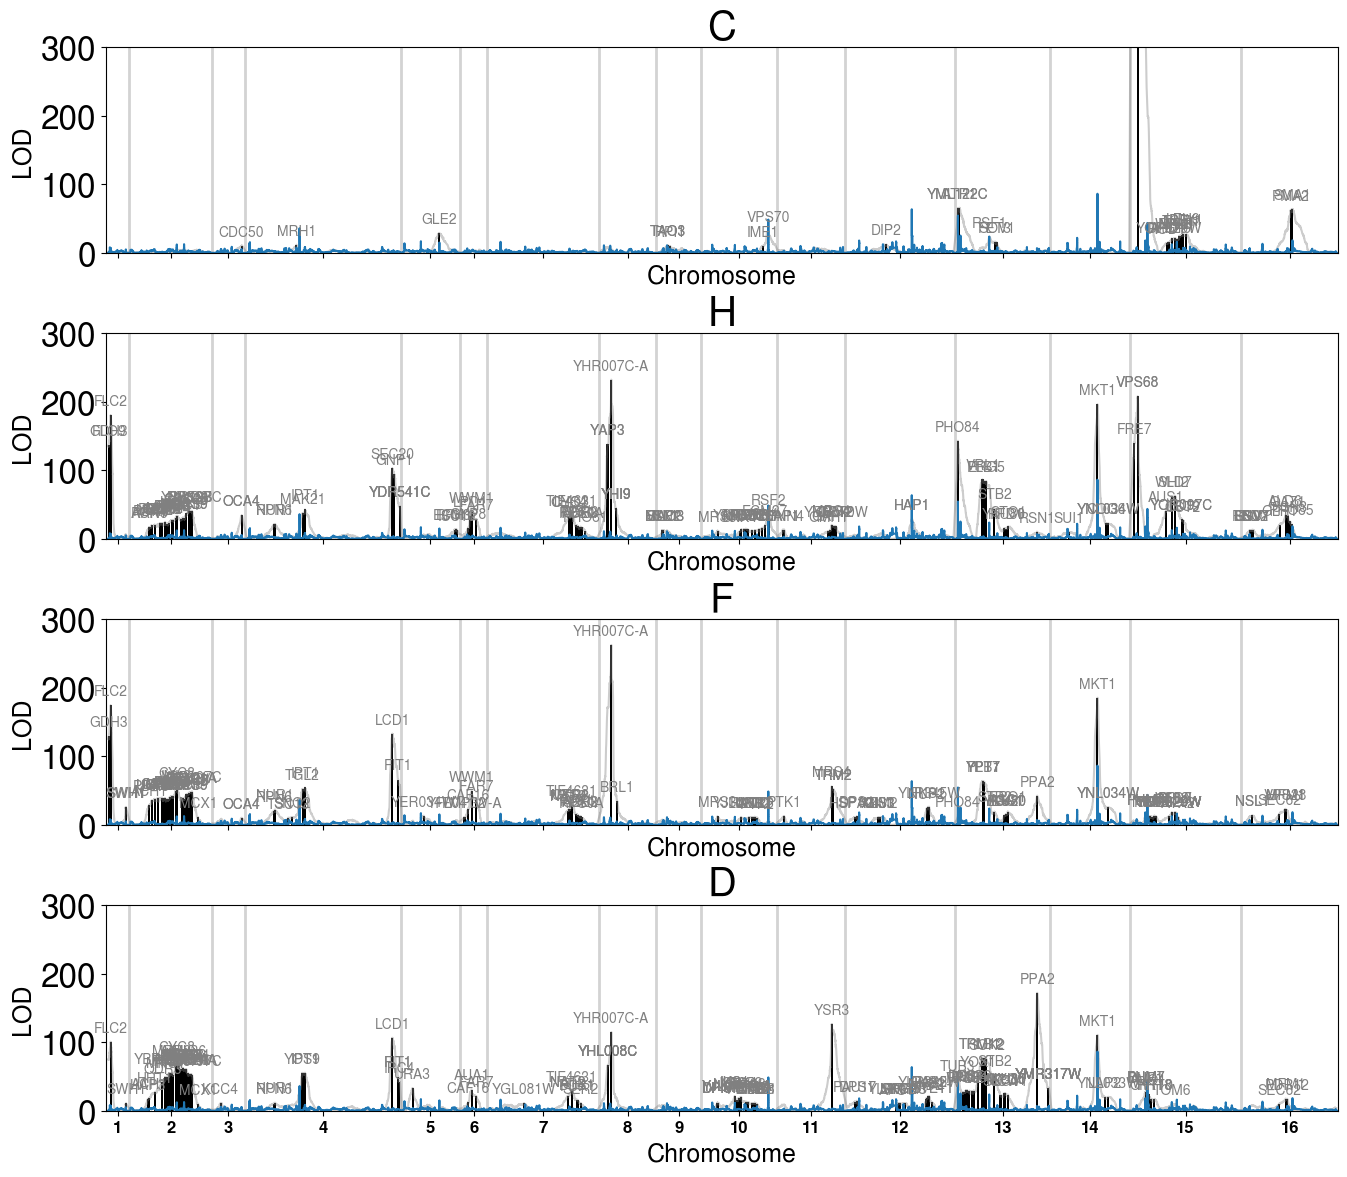

In [18]:
pleio_track = pd.read_csv("data/pleiotropic_CI.csv") # SNP pleiotropic effects, derived from Alex's 2021 eLife paper
geno_data.snp_info['pleio_score'] = list(pleio_track.loc[geno_data.snp_info.abs_pos]['CI_track'])

plt.rcParams.update({
    'font.size': 24,
    'font.family': 'Nimbus Sans'  
})

treatments = ['C', 'H', 'F', 'D']

fig, axs = plt.subplots(len(treatments), 1, sharex=True, figsize=(14, 12))  # one column

for ax, treatment in zip(axs, treatments):
    df_plot = pd.DataFrame({"LOD": LODS_df[treatment]})
    make_man(df_plot, geno_data.snp_info, ax, 'LOD', bg_color=pleio_track, ylab='LOD', label_genes=True)
    # maybe set title or label on each subplot
    ax.set_title(f"{treatment}")

# Adjust left margin so there's a consistent space for y-tick labels
fig.subplots_adjust(left=0.2, hspace=0.)

# Align y-labels (so label text boxes line up) using:
fig.align_ylabels(axs)

plt.tight_layout()

# fig.savefig("figures/Pulvinatal_LOD_treatments.pdf", format="pdf", bbox_inches="tight")
fig.savefig("figures/Pulvinatal_LOD_treatments.png", format="png", bbox_inches="tight")

plt.show()

In [21]:
print("LODS_df shape:", LODS_df.shape)
print("LODS_df index head:", LODS_df.index[:10])

print("snp_info shape:", geno_data.snp_info.shape)
print("snp_info index head:", geno_data.snp_info.index[:10])

print("snp_info columns:", geno_data.snp_info.columns.tolist())

LODS_df shape: (37339, 4)
LODS_df index head: Index([0, 1, 2, 3, 4, 6, 12, 13, 15, 19], dtype='int64')
snp_info shape: (41594, 12)
snp_info index head: Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')
snp_info columns: ['SNP', 'Chromosome', 'Position (bp)', 'BY allele', 'RM allele', 'feature_type', 'gene_name', 'gene_chr_start', 'gene_chr_end', 'gene_standard_name', 'abs_pos', 'pleio_score']


In [22]:
# Export per-SNP LOD table using the SNP subset that matches LODS_df

lod_export = pd.DataFrame(LODS_df).copy()

# Align snp_info to the LODS_df subset using index
snp_info_subset = geno_data.snp_info.loc[LODS_df.index].copy()

# Add SNP identity columns if available
insert_pos = 0

if "Index" in snp_info_subset.columns:
    lod_export.insert(insert_pos, "Index", snp_info_subset["Index"].values)
    insert_pos += 1

if "SNP" in snp_info_subset.columns:
    lod_export.insert(insert_pos, "SNP", snp_info_subset["SNP"].values)
    insert_pos += 1

# Optional useful columns
if "Chromosome" in snp_info_subset.columns:
    lod_export.insert(insert_pos, "Chromosome", snp_info_subset["Chromosome"].values)
    insert_pos += 1

if "Position (bp)" in snp_info_subset.columns:
    lod_export.insert(insert_pos, "Position (bp)", snp_info_subset["Position (bp)"].values)
    insert_pos += 1

lod_export.to_csv("data/Pulvinatal_LOD_per_snp.csv", index=False)

print(lod_export.shape)
lod_export.head()

(37339, 7)


,SNP,Chromosome,Position (bp),C,H,F,D
0,snp1,1,27210,1.530708,134.600075,124.905667,74.193223
1,snp2,1,27290,1.552951,134.521658,124.752968,74.114626
2,snp3,1,27356,1.543347,134.719018,125.096943,74.437818
3,snp4,1,27357,1.543347,134.719018,125.096943,74.437818
4,snp5,1,27370,1.538815,134.537615,124.909982,74.259026


In [23]:
test_lod = pd.read_csv("data/Pulvinatal_LOD_per_snp.csv")
print(test_lod.shape)
print(test_lod.columns.tolist())
test_lod.head()

(37339, 7)
['SNP', 'Chromosome', 'Position (bp)', 'C', 'H', 'F', 'D']


,SNP,Chromosome,Position (bp),C,H,F,D
0,snp1,1,27210,1.530708,134.600075,124.905667,74.193223
1,snp2,1,27290,1.552951,134.521658,124.752968,74.114626
2,snp3,1,27356,1.543347,134.719018,125.096943,74.437818
3,snp4,1,27357,1.543347,134.719018,125.096943,74.437818
4,snp5,1,27370,1.538815,134.537615,124.909982,74.259026


### generate summaries

In [16]:
snp_gene_info_df = pd.read_csv("./data/snp_info_complete.tsv", sep='\t')
gene_info_df = pd.read_csv("./data/gene_info.csv")

# Functions for generating the summary table of QTL results

def find_limit(peak, track, snp_info, threshold, step):
    # find the segment of SNPs containing causal SNP with 95 percent confidence
    chrom = snp_info['Chromosome'][peak] # chrom number of the peak
    pos = np.where(track.index == peak)[0][0] # position of the peak on the input track df, not SNP id
    i = 0
    while (track.iloc[pos + i] > threshold) & (snp_info['Chromosome'][list(track.index)[pos + i]] == chrom):
        i += step
        i = int(i)
    return list(track.index)[pos + i - 1]

def get_lod_interval(peak, lod_track, snp_info, tolerance=1.5):
    """
    peak: id of peak snp in original indexing (42000 snps)
    """
    # peak_id = np.where(lod_track.index == peak)[0][0]
    threshold = lod_track.loc[peak] - tolerance
    limits_id = [find_limit(peak, lod_track, snp_info, threshold, -1), find_limit(peak, lod_track, snp_info, threshold, +1)]
    # limits = [lod_track.index[limits_id[0]], lod_track.index[limits_id[1]]]
    
    return limits_id

def map_to_chr_pos(snp_id, snp_info):
    """
    snp_info: panda df with SNP id as index, contaning columns
    'Chromsome' and 'Position (bp)'
    """
    chrom = snp_info.loc[snp_id]['Chromosome']
    pos = snp_info.loc[snp_id]['Position (bp)']
    return chrom, pos

def get_seg_chrom_pos(seg_start, seg_end, snp_info):
    (seg_chrom, seg_chr_start), (_, seg_chr_end) = map_to_chr_pos(seg_start, snp_info), map_to_chr_pos(seg_end, snp_info)
    
    return seg_chrom, seg_chr_start, seg_chr_end

def gene_in_interval(gene_info, seg_info, padding=0):
    """
    gene_info, seg_info: chrom, chrom_start, chrom_end
    """
    gene_chrom, gene_chr_start, gene_chr_end = gene_info
    seg_chrom, seg_chr_start, seg_chr_end = seg_info
    
    if gene_chrom == seg_chrom:
        gene_range = np.arange(gene_chr_start, gene_chr_end)
        seg_range = np.arange(seg_chr_start - padding, seg_chr_end + padding)
        overlap = np.intersect1d(gene_range, seg_range)
        
        return len(overlap) != 0
    else: 
        return False

def get_all_genes_in_segment(seg_info, gene_info_df):
    genes_in_segment = []
    genes_in_segment_std = []
    for i in range(len(gene_info_df)):
        gene_info = list(gene_info_df.iloc[i][["chrom", "gene_chr_start", "gene_chr_end"]])
        gene_name, gene_standard_name = gene_info_df.iloc[i][['gene_name', 'Standard_name']]
        if gene_in_interval(gene_info, seg_info, padding=1000):
            genes_in_segment.append(gene_name)
            genes_in_segment_std.append(gene_standard_name)
    return ", ".join(genes_in_segment), ", ".join(genes_in_segment_std)

In [17]:
treatment = 'F'
df_plot = pd.DataFrame({"LOD": LODS_df[treatment]})
df_plot, df_plot_max = make_df_plot(df_plot, geno_data.snp_info)
peaks = list(df_plot_max.index)
lod_track = df_plot['LOD']

In [18]:
# find overlapping genes

intervals = {}
for peak in peaks:
    try:
        intervals[peak] = get_lod_interval(peak, lod_track, geno_data.snp_info, tolerance=2.)
    except: 
        pass

In [19]:
from scipy import stats

interval_df = {}

for interval_id in intervals.keys():
    seg_start, seg_end = intervals[interval_id]
    seg_info = get_seg_chrom_pos(seg_start, seg_end, geno_data.snp_info)
    seg_chrom, seg_start, seg_end = seg_info
    
    genes_in_segment, genes_in_segment_std = get_all_genes_in_segment(seg_info, gene_info_df)
    
    abs_start, abs_end = get_abs_pos(seg_chrom, seg_start), get_abs_pos(seg_chrom, seg_end)
    seg_pleio_score = pleio_track[abs_start: abs_end].CI_track.max()
    seg_pleio_percentile = stats.percentileofscore(geno_data.snp_info.loc[geno_data.loci_chosen]['pleio_score'], seg_pleio_score, kind='rank')
    
    df_data = {"interval_id": interval_id, "chrom": seg_chrom, "start": seg_start, "end": seg_end, 
               "genes": genes_in_segment, "genes_std": genes_in_segment_std, 'pleio_score': seg_pleio_score, 
              'pleio_percentile': seg_pleio_percentile}
    interval_df[interval_id] = df_data

interval_df = pd.DataFrame(interval_df).T
interval_df['lod_max'] = lod_track.loc[peaks]

interval_df.to_csv("results/Pulvinatal_QTL_genes_20260330.csv", index=None)

In [20]:
interval_df['n_genes'] = [len(s.split(",")) for s in interval_df.genes]

In [21]:
interval_df.sort_values(by='n_genes', ascending=False)

,interval_id,chrom,start,end,genes,genes_std,pleio_score,pleio_percentile,lod_max,n_genes
4386,4386,2,159079,675153,"YBL034C, YBL033C, YBL032W, YBL031W, YBL030C, Y...","STU1, RIB1, HEK2, SHE1, PET9, YBL029C-A, YBL02...",0.063315,99.667908,10.963583,265
1761,1761,2,216631,630110,"YBL007C, YBL006C, YBL005W, YBL004W, YBL003C, Y...","SLA1, LDB7, PDR3, UTP20, HTA2, HTB2, ECM15, NT...",0.063315,99.667908,35.456585,211
3240,3240,2,377765,629736,"YBR069C, YBR070C, YBR071W, YBR072W, YBR072C-A,...","TAT1, ALG14, YBR071W, HSP26, YBR072C-A, RDH54,...",0.063315,99.667908,37.060281,143
6881,6881,4,421542,678135,"YDL019C, YDL017W, YDL016C, YDL015C, YDL014W, Y...","OSH2, CDC7, TSC13, TSC13, NOP1, SLX5, YDL012C,...",0.179946,99.973218,10.321640,112
7039,7039,4,443547,674432,"YDL004W, YDL003W, YDL002C, YDL001W, YDR001C, Y...","ATP16, MCD1, NHP10, RMD1, NTH1, YRB1, RCR2, YD...",0.179946,99.973218,11.468610,97
...,...,...,...,...,...,...,...,...,...,...
3336,3336,2,518432,526183,"YBR140C, YBR141C","IRA1, BMT2",0.010412,59.38429,39.331077,2
16914,16914,8,121313,122368,"YHR007C, YHR007C-A","ERG11, YHR007C-A",0.007006,37.905407,262.702991,2
26745,26745,12,109886,114659,"YLL018C-A, YLL018C","COX19, DPS1",0.013917,74.931037,12.511412,2
896,896,1,193452,196587,YAR042W,SWH1,0.025053,94.677147,25.565938,1


In [23]:
# plotting function for visualizing arbitrary chromosome segments

def plot_track(df_plot, snp_info, value, chrom=None, chrom_range=None, constrained_layout=False):
    df_plot, df_plot_max = make_df_plot(df_plot, snp_info)
    abs_pos = df_plot_max['abs_pos']
    y = df_plot_max.iloc[:, 0]
    ylab = value

    fig, ax = plt.subplots(figsize=(30, 10), gridspec_kw={'left': 0.4}, constrained_layout=constrained_layout)
    ax.set_box_aspect(1/6)
    
    # Plot main effect track
    ax.plot(
        df_plot['abs_pos'],
        df_plot[value],
        color='gray',
        lw=1.5,
        zorder=2, 
        alpha=.4
    )
    
    # Plot pleiotropic track
    ax.plot(
        pleio_track["abs_pos"], 
        200 * pleio_track["CI_track"]
    )
    
    # Draw vertical lines for chromosome boundaries
    for offset in chr_offsets[1:]:
        ax.axvline(offset, color='lightgray', lw=2, zorder=0)

    # Set x‐ticks at chromosome midpoints
    midpoints = [offset + length/2 for offset, length in zip(chr_offsets, yeast_chr_lengths)]
    ax.set_xticks(midpoints)
    ax.set_xticklabels(chr_labels_arabic, fontsize=12, fontweight='bold')
    if chrom is None:
        ax.set_xlim(0, yeast_chr_size)
        ax.set_xlabel('Chromosome', fontsize=18)
        
    else:
        chrom = chrom - 1
        chrom_size = chr_offsets[chrom + 1] - chr_offsets[chrom]
        
        ax.set_xticks(range(chr_offsets[chrom], chr_offsets[chrom + 1], 10000))
        xticks = np.arange(0, chrom_size, 10000)/10000
        xticks = np.array(xticks, int)
        ax.set_xticklabels(xticks)
        ax.set_xlabel('Chromosome position (10kb)', fontsize=18)        
        ax.set_title(f'Chromomsome {chrom + 1}')
        
        gene_info_chrom = gene_info_df[gene_info_df.chrom == chrom + 1].iloc[:, 1:]
        if chrom_range is not None:
            gene_info_chrom = gene_info_chrom[(gene_info_chrom['gene_chr_start'] > chrom_range[0]) & (gene_info_chrom['gene_chr_start'] < chrom_range[1])]
        for k in range(len(gene_info_chrom)):
            plot_gene(ax, *gene_info_chrom.iloc[k])
            
    
        if chrom_range is None:
            ax.set_xlim(chr_offsets[chrom], chr_offsets[chrom + 1])
        else:
            ax.set_xlim(chr_offsets[chrom] + chrom_range[0], chr_offsets[chrom] + chrom_range[1])

        # fig, ax = plt.subplots(figsize=(14, 4), gridspec_kw={'left': 0.4}, constrained_layout=constrained_layout)
        ax.set_box_aspect(1/6)

        ax.scatter(
            df_plot['abs_pos'],
            df_plot[value],
            color='gray',
            lw=1.5,
            zorder=2, 
            alpha=.4
        )
        
#     ax.set_ylabel(f'{ylab}', fontsize=18)
#     ax.margins(x=0)
    
    return ax

def plot_gene(ax, chrom, chr_start, chr_end, gene_name):
    abs_start, abs_end = get_abs_pos(chrom, chr_start), get_abs_pos(chrom, chr_end)
    ax.hlines(y=10, xmin=abs_start, xmax=abs_end, colors='red', linewidth=1)

    ax.text(
        (abs_start + abs_end) / 2,   # x position: midpoint of interval
        10 + 0.1,         # y position: slightly above the line
        gene_name,   # label
        ha='center',     # center horizontally
        va='bottom',      # anchor text at its bottom
        fontsize=12
    )

In [25]:
# Search any gene table you have
gene_info_df[gene_info_df.astype(str).apply(lambda c: c.str.contains(r"\bERG11\b", na=False)).any(axis=1)].head(10)

,gene_name,chrom,gene_chr_start,gene_chr_end,Standard_name
2093,YHR007C,8,120091,121683,ERG11


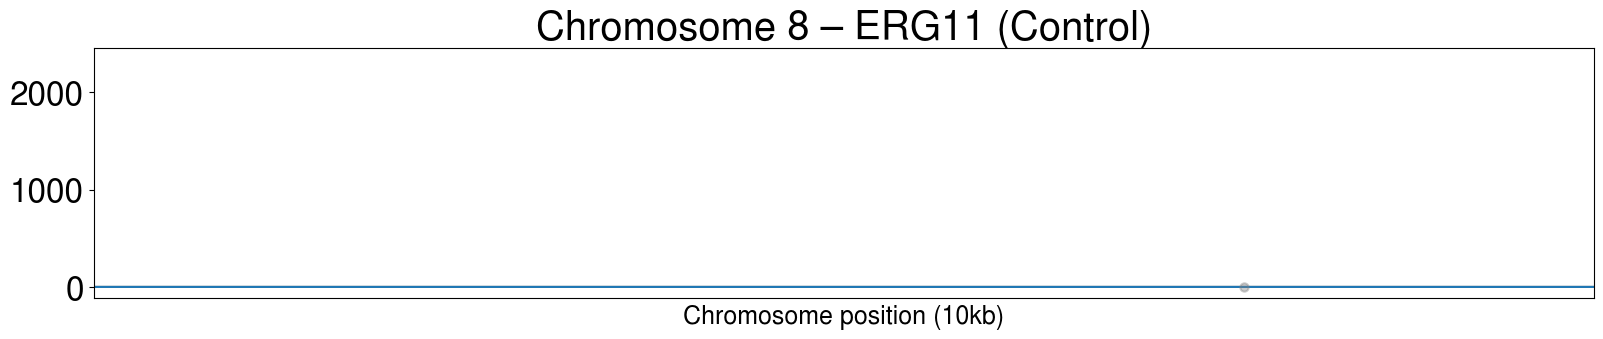

In [26]:
df_plot = pd.DataFrame({"LOD": LODS_df["C"]})

plot_track(
    df_plot,
    geno_data.snp_info,
    "LOD",
    chrom=8,
    chrom_range=[120091, 121683]
)

plt.title("Chromosome 8 – ERG11 (Control)")
plt.show()

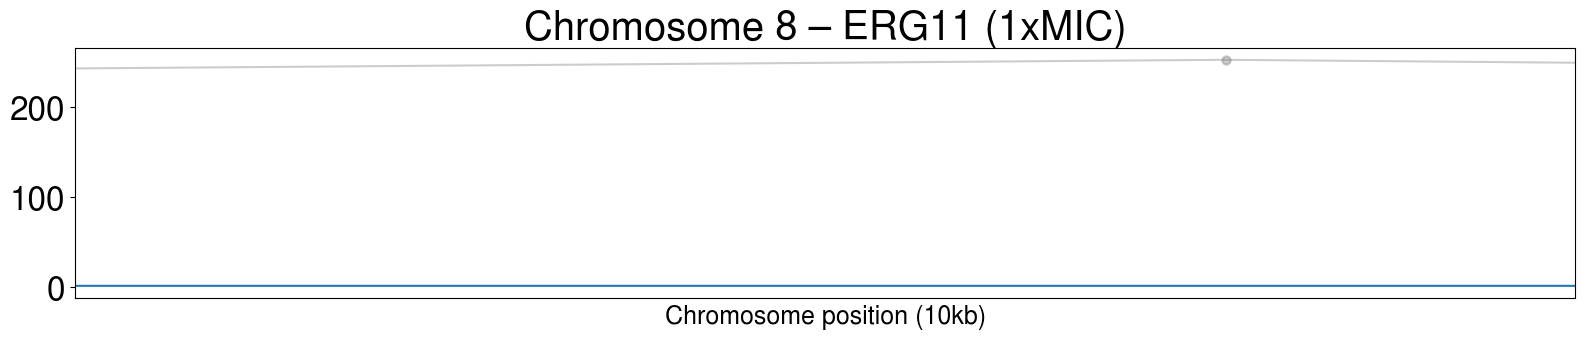

In [31]:
df_plot = pd.DataFrame({"LOD": LODS_df["F"]})

plot_track(
    df_plot,
    geno_data.snp_info,
    "LOD",
    chrom=8,
    chrom_range=[120091, 121683]
)

plt.title("Chromosome 8 – ERG11 (1xMIC)")
plt.show()

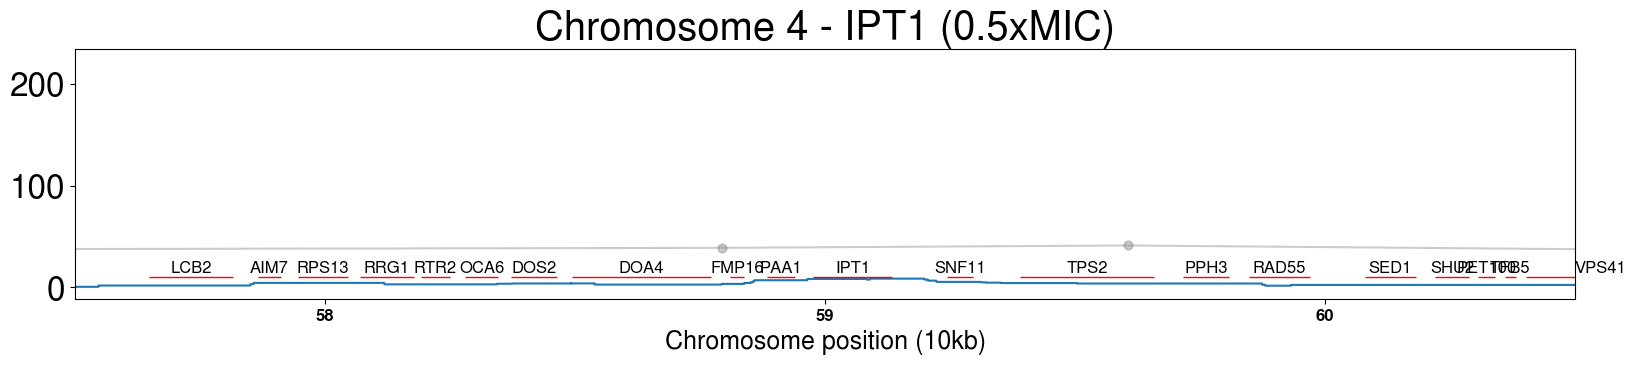

In [33]:
df_plot = pd.DataFrame({"LOD": LODS_df["H"]})  # change to H/F/D if needed

plot_track(
    df_plot,
    geno_data.snp_info,
    "LOD",
    chrom=4,
    chrom_range=[575000, 605000]
)

plt.title("Chromosome 4 - IPT1 (0.5xMIC)")
plt.show()

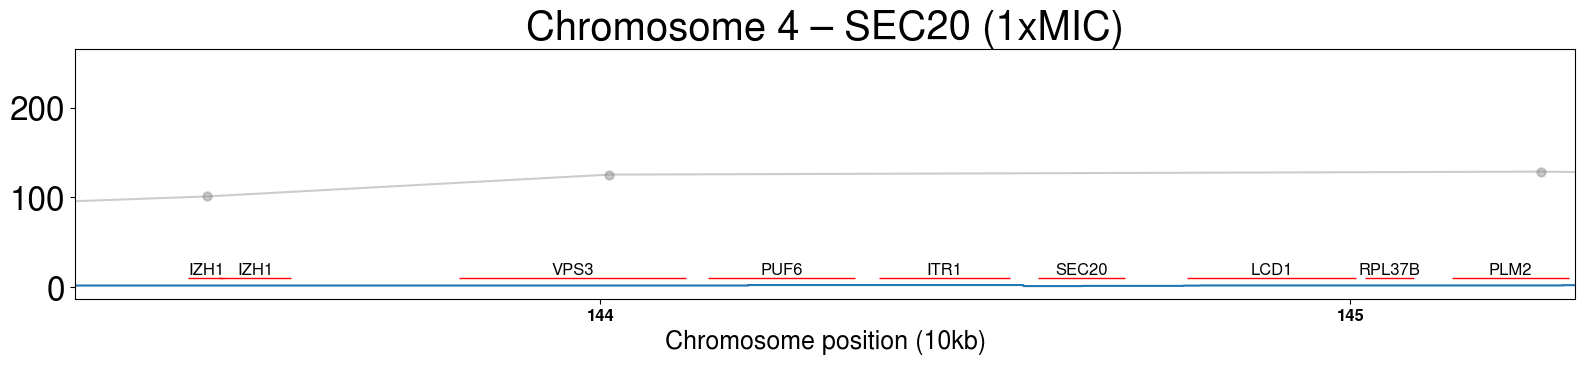

In [36]:
df_plot = pd.DataFrame({"LOD": LODS_df["F"]})  # change to C/H/D if needed

plot_track(
    df_plot,
    geno_data.snp_info,
    "LOD",
    chrom=4,
    chrom_range=[1433000, 1453000]
)

plt.title("Chromosome 4 – SEC20 (1xMIC)")
plt.show()

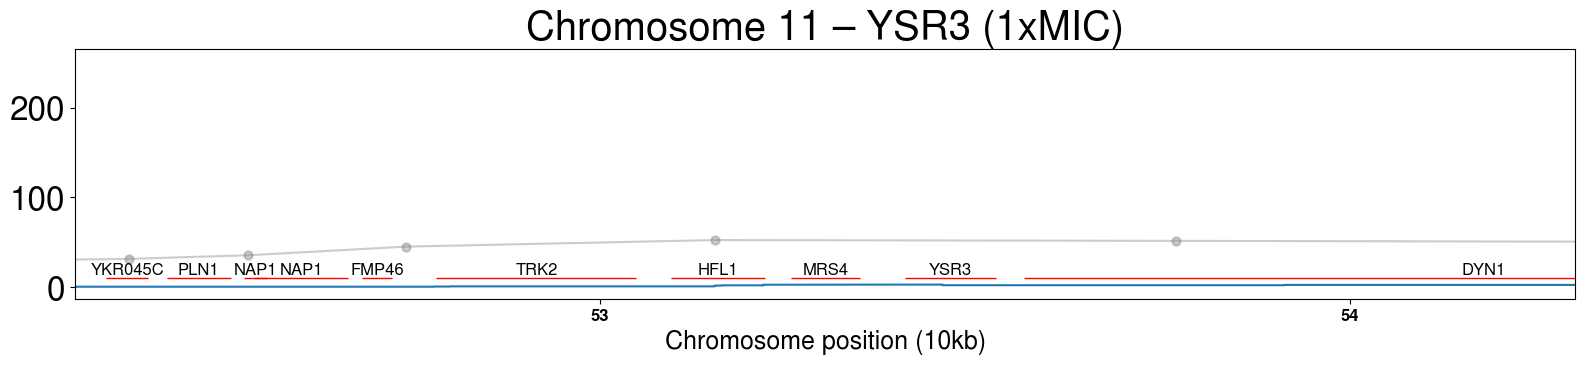

In [38]:
df_plot = pd.DataFrame({"LOD": LODS_df["F"]})

plot_track(
    df_plot,
    geno_data.snp_info,
    "LOD",
    chrom=11,
    chrom_range=[523000, 543000]
)

plt.title("Chromosome 11 – YSR3 (1xMIC)")
plt.show()

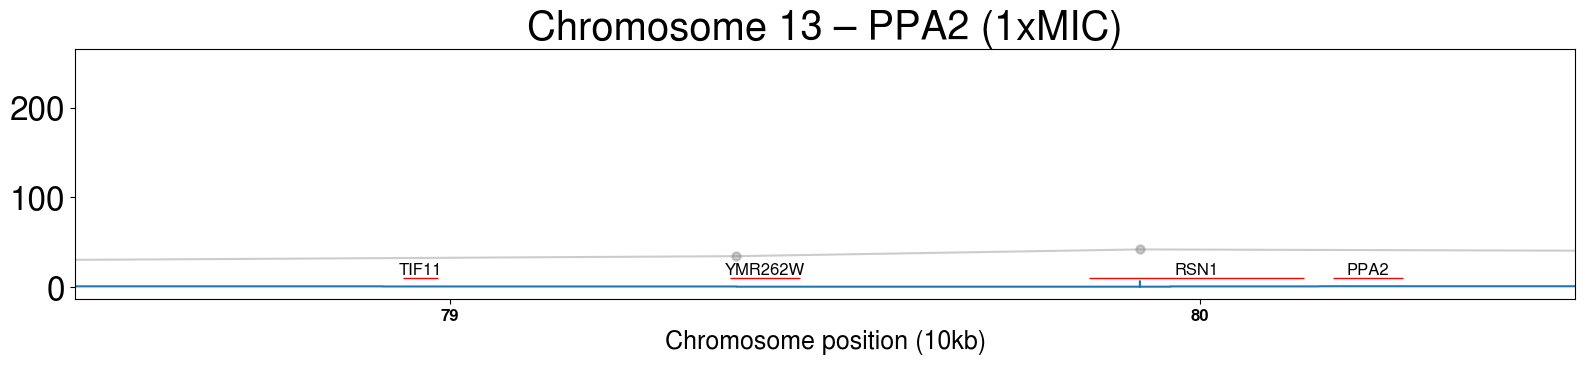

In [40]:
df_plot = pd.DataFrame({"LOD": LODS_df["F"]})

plot_track(
    df_plot,
    geno_data.snp_info,
    "LOD",
    chrom=13,
    chrom_range=[785000, 805000]
)

plt.title("Chromosome 13 – PPA2 (1xMIC)")
plt.show()